# MuMax3 Nanotube General Analysis Notebook

Generalised notebook for the **hollow-cylinder (nanotube)** phase-diagram scan.
Set the folder path below and run all cells.

**Output structure expected:**
```
<SIM_DIR>/
  table.txt          (scalar time-series (MuMax3 table))
  m_<iD>_<iH>.ovf    (one spin texture per (Dind, B_rad) point)
```


## 0. Configuration

In [1]:
# Imports
import discretisedfield as df
import ubermagtable as ut
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import glob, os

# Template
plt.style.use('/Users/itxaso/MASTER-codi/2-TFM/MUMAX3/mplstyle/science.mplstyle')
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'

In [2]:
# Simulation folder
SIM_DIR = 'setA-Cortes-Ortuno/setA.out'

os.system(f'cd {SIM_DIR} && mkdir plots')

PLOTS_DIR = 'setA-Cortes-Ortuno/setA.out/plots'

# Simulation parameters
N_D = 11   # number of Dind steps
N_H = 11   # number of B_rad steps

# Search the snapshots
ovf_files = sorted(glob.glob(os.path.join(SIM_DIR, 'm_*.ovf')))
print(f'Folder  : {SIM_DIR}')
print(f'Created plots folder  : {PLOTS_DIR}')
print(f'Snapshots found: {len(ovf_files)}  (expected {N_D*N_H})')

# Load one field to inspect the mesh
if ovf_files:
    sample = df.Field.from_file(ovf_files[0])
    print(f'Grid    : {sample.mesh.n}')
    print(f'Cell    : {np.array(sample.mesh.cell)*1e9} nm')
    print(f'Region  : {np.array(sample.mesh.region.pmin)*1e9} --> {np.array(sample.mesh.region.pmax)*1e9} nm')

Folder  : setA-Cortes-Ortuno/setA.out
Created plots folder  : setA-Cortes-Ortuno/setA.out/plots
Snapshots found: 121  (expected 121)
Grid    : [32 32 80]
Cell    : [2. 2. 2.] nm
Region  : [0. 0. 0.] --> [ 64.  64. 160.] nm


mkdir: plots: File exists


## 1. Scalar table (averages vs scan index)

In [3]:
table = ut.Table.fromfile(os.path.join(SIM_DIR, 'table.txt'))
print(table.data.columns.tolist())
table.data.head()

['t', 'mx', 'my', 'mz', 'Dind', 'B_extx', 'B_exty', 'B_extz']


,t,mx,my,mz,Dind,B_extx,B_exty,B_extz
0,0.0,2.543516e-10,1.329526e-09,-1.000000,0.0,0.000000,0.000000,0.0
1,0.0,1.038667e-02,-3.934948e-02,-0.998467,0.0,0.003702,-0.018189,0.0
2,0.0,2.077159e-02,-7.869906e-02,-0.993856,0.0,0.007404,-0.036379,0.0
3,0.0,3.115291e-02,-1.180487e-01,-0.986126,0.0,0.011107,-0.054568,0.0
4,0.0,4.152868e-02,-1.573979e-01,-0.975210,0.0,0.014809,-0.072757,0.0


## 2. Phase diagram of m components in the (D, B) plane

Reshape the scalar table into an N_D × N_H grid.

The scan loops outer=iD, inner=iH.


Saved phase_diagram_mz.pdf


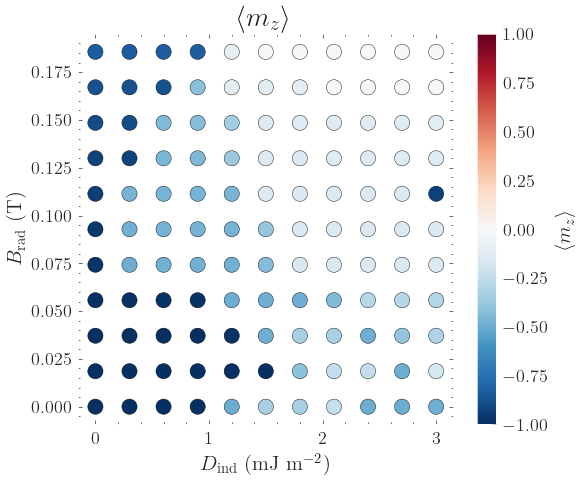

Saved phase_diagram_mx.pdf


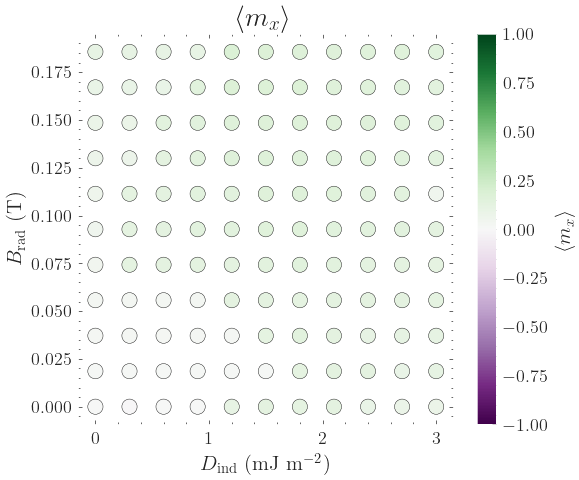

Saved phase_diagram_my.pdf


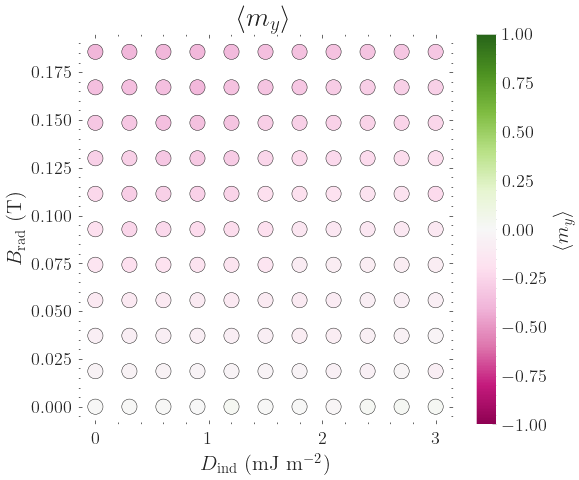

In [4]:
# Build coordinate columns from scan indices
df_t = table.data.copy()
df_t['B_rad'] = np.sqrt(df_t['B_extx']**2 + df_t['B_exty']**2)
df_t['iD']    = np.repeat(np.arange(N_D), N_H)
df_t['iH']    = np.tile(np.arange(N_H), N_D)

# Phase diagram scatter (one for each m component)
PARAM_LATEX = {
    'Dind':  r'$D_\mathrm{ind}$ (mJ m$^{-2}$)',
    'B_rad': r'$B_\mathrm{rad}$ (T)',
    'mx':    r'$\langle m_x \rangle$',
    'my':    r'$\langle m_y \rangle$',
    'mz':    r'$\langle m_z \rangle$',
}

def plot_phase_diagram(df, xkey, ykey, zkey, xlabel=None, ylabel=None, clabel=None,
                       cmap='RdBu_r', vmin=-1, vmax=1, savename=None):
    fig, ax = plt.subplots(figsize=(6, 5))

    ax.set_facecolor('white')

    sc = ax.scatter(
        df[xkey] * 1e3,           # J/m^2 to mJ/m^2
        df[ykey],                  # T
        c=df[zkey],
        cmap=cmap, s=120,
        vmin=vmin, vmax=vmax,
        edgecolors='k'
    )
    plt.colorbar(sc, ax=ax, label=clabel or PARAM_LATEX.get(zkey, zkey))
    ax.set_xlabel(xlabel or PARAM_LATEX.get(xkey, xkey))
    ax.set_ylabel(ylabel or PARAM_LATEX.get(ykey, ykey))
    ax.set_title(clabel or PARAM_LATEX.get(zkey, zkey))
    ax.grid(alpha=0.2)
    plt.tight_layout()
    if savename:
        plt.savefig(os.path.join(PLOTS_DIR, savename), bbox_inches='tight')
        print(f"Saved {savename}")
    plt.show()
    plt.close(fig)

for comp, cmap in [('mz', 'RdBu_r'), ('mx', 'PRGn'), ('my', 'PiYG')]:
    plot_phase_diagram(
        df_t,
        xkey='Dind', ykey='B_rad', zkey=comp,
        clabel=PARAM_LATEX[comp],
        cmap=cmap,
        savename=f'phase_diagram_{comp}.pdf'
    )



## 3. Single snapshot — cross-sections

Pick any `(iD, iH)` point and inspect it in detail.


In [ ]:
# Choose the snapshot 
iD_plot = 10   # D index  (0 .. N_D-1)
iH_plot = 10   # B index  (0 .. N_H-1)

fname = os.path.join(SIM_DIR, f'm_{iD_plot}_{iH_plot}.ovf')
field = df.Field.from_file(fname)
print(f'Loaded: {fname}')

# Cross-sections along z
Nz = field.mesh.n[2]
z_indices = [Nz // 4, Nz // 2, 3 * Nz // 4]
z_coords  = [field.mesh.region.pmin[2] + (i + 0.5) * field.mesh.cell[2]
             for i in z_indices]

fig, axes = plt.subplots(2, len(z_indices), figsize=(5*len(z_indices), 8))
for col, (iz, zc) in enumerate(zip(z_indices, z_coords)):

    # top row: mz colourmap
    field.sel(z=zc).z.mpl.scalar(ax=axes[0][col], cmap='RdBu_r', colorbar=True)
    axes[0][col].set_title(f'mz, z={zc*1e9:.0f} nm')

    # bottom row: mx + arrows
    field.sel(z=zc).x.mpl.scalar(ax=axes[1][col], cmap='RdBu_r', colorbar=True)
    field.sel(z=zc).resample(n=(12, 12)).mpl.vector(
        ax=axes[1][col], use_color=False, color='black')
    axes[1][col].set_title(f'mx + arrows, z={zc*1e9:.0f} nm')

plt.suptitle(f'Cross-sections iD={iD_plot}, iH={iH_plot}', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f'cross_sections_{iD_plot}_{iH_plot}.png'), dpi=150, bbox_inches='tight')
plt.show()


Loaded: setA-Cortes-Ortuno/setA.out/m_10_10.ovf


## 4. Longitudinal slice (xz plane at y ≈ 0)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
y_mid = 0.0
for ax, comp in zip(axes, ['x', 'y', 'z']):
    getattr(field.sel(y=y_mid), comp).mpl.scalar(
        ax=ax, cmap='RdBu_r', colorbar=True)
    ax.set_title(f'm{comp}  (y=0 slice)')
plt.suptitle(f'Longitudinal slice — iD={iD_plot}, iH={iH_plot}', fontsize=12)
plt.tight_layout()
plt.savefig(f'longitudinal_{iD_plot}_{iH_plot}.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. 3D interactive (k3d)

In [17]:
try:
    import k3d
    field.x.k3d.scalar(filter_field=field.norm)
except ImportError:
    print('k3d not installed — run:  pip install k3d')


Output()

In [ ]:
import os
import discretisedfield as df

OUT_DIR = "setA-Cortes-Ortuno/setA-Hrad.out"   # change to your actual path

# list all saved magnetisation files
ovf_files = sorted([f for f in os.listdir(OUT_DIR) if f.endswith(".ovf")])
print(ovf_files)   # e.g. ['m_0_0.ovf', 'm_0_1.ovf', ..., 'm_10_10.ovf']

# pick ONE snapshot by (iD, iH) index
iD, iH = 5, 3    # ← change these to the point in the phase diagram you want
filename = f"m_{iD}_{iH}.ovf"
field = df.Field.from_file(os.path.join(OUT_DIR, filename))
print(f"Loaded: {filename}  |  grid: {field.mesh.n}")

In [ ]:
import k3d

plot = k3d.plot()

# scalar: mz coloured by norm, masked to magnetic region
field.x.k3d.scalar(
    filter_field=field.norm,   # hides vacuum cells
    #plot=plot,
    #color_map='RdBu',
    #name=f"mz  [{filename}]"
)

# overlay: arrows showing full m vector (subsample to keep it fast)
#field.k3d.vector(
#    filter_field=field.norm,
    #plot=plot,
#    head_size=2.0,
#    scale=2e-9,
#    name="m vectors"
#)

plot.display()

In [ ]:
import k3d
import numpy as np
import time

# ── load ALL snapshots for one fixed D value ─────────────────────
iD_fixed = 5   # fix D, sweep H

snapshots = []
labels    = []
for iH in range(11):
    fname = os.path.join(OUT_DIR, f"m_{iD_fixed}_{iH}.ovf")
    if os.path.exists(fname):
        snapshots.append(df.Field.from_file(fname))
        labels.append(f"iD={iD_fixed}  iH={iH}")

print(f"Loaded {len(snapshots)} snapshots")

# ── build the k3d animation ───────────────────────────────────────
plot = k3d.plot()

# pre-compute all mz arrays (shape: Nx, Ny, Nz, float32)
arrays = [s.z.array.astype(np.float32) for s in snapshots]

# create the volume object with the first frame
vol = k3d.volume(
    arrays[0],
    #color_map='RdBu',
    color_range=[-1, 1],
    alpha_coef=50,
    name=labels[0]
)
plot += vol
plot.display()

# ── playback loop (run this cell; interrupt kernel to stop) ───────
import time
for i, arr in enumerate(arrays):
    vol.volume    = arr          # update data in-place
    vol.name      = labels[i]    # update label
    time.sleep(0.8)              # seconds per frame — adjust freely

In [ ]:
import ipywidgets as widgets
from IPython.display import display

plot = k3d.plot()
vol  = k3d.volume(
    arrays[0],
    #color_map=k3d.colormaps.matplotlib_color_maps.RdBu,
    color_range=[-1, 1],
    alpha_coef=50
)
plot += vol
plot.display()

slider = widgets.IntSlider(value=0, min=0, max=len(arrays)-1,
                           description='iH frame:')
label  = widgets.Label(value=labels[0])

def update(change):
    i = change['new']
    vol.volume = arrays[i]
    label.value = labels[i]

slider.observe(update, names='value')
display(widgets.HBox([slider, label]))

## 6. Azimuthal spin profile — ring at mid-z

Sample the magnetisation on a circle at `r_sample` and `z_mid`.


In [ ]:
# Geometry (must match your .mx3)
R_sample = 27e-9   # m — mid-shell radius  (R_in + R_out) / 2
N_phi    = 64      # number of azimuthal sample points


cx = (field.mesh.region.pmin[0] + field.mesh.region.pmax[0]) / 2
cy = (field.mesh.region.pmin[1] + field.mesh.region.pmax[1]) / 2
cz = (field.mesh.region.pmin[2] + field.mesh.region.pmax[2]) / 2

phi  = np.linspace(0, 2 * np.pi, N_phi, endpoint=False)
xs = cx + R_sample * np.cos(phi)   # was just R_sample * cos(phi)
ys = cy + R_sample * np.sin(phi)
z_mid = cz

mx_ring = [field((x, y, z_mid))[0] for x, y in zip(xs, ys)]
my_ring = [field((x, y, z_mid))[1] for x, y in zip(xs, ys)]
mz_ring = [field((x, y, z_mid))[2] for x, y in zip(xs, ys)]

# Radial and tangential components
mr   = [mx * np.cos(p) + my * np.sin(p)
        for mx, my, p in zip(mx_ring, my_ring, phi)]
mphi = [-mx * np.sin(p) + my * np.cos(p)
        for mx, my, p in zip(mx_ring, my_ring, phi)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
phi_deg = np.degrees(phi)
axes[0].plot(phi_deg, mr,    label=r'$m_r$')
axes[0].plot(phi_deg, mphi,  label=r'$m_\phi$')
axes[0].plot(phi_deg, mz_ring, label=r'$m_z$')
axes[0].set_xlabel(r'$\phi$ (deg)')
axes[0].set_ylabel('component')
axes[0].set_title('Azimuthal spin profile')
axes[0].legend()
axes[0].axhline(0, color='k', lw=0.5, ls='--')

axes[1].quiver(xs * 1e9, ys * 1e9, mx_ring, my_ring,
               scale=15, color='steelblue')
axes[1].set_xlabel('x (nm)')
axes[1].set_ylabel('y (nm)')
axes[1].set_title('In-plane arrows on ring')
axes[1].set_aspect('equal')

plt.suptitle(f'Azimuthal profile — iD={iD_plot}, iH={iH_plot}', fontsize=12)
plt.tight_layout()
plt.savefig(f'azimuthal_{iD_plot}_{iH_plot}.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Unfolded

In [ ]:
def unfold_nanotube(field, component="mphi", n_phi=128, z_slice=None):
    """
    Unroll a nanotube field onto a (phi, z) plane.

    Parameters
    ----------
    field     : discretisedfield.Field  — full 3D magnetisation
    component : "mr" | "mphi" | "mz" | "mx" | "my"
    n_phi     : azimuthal resolution of the output grid
    z_slice   : None → average over annulus radial thickness,
                int  → use only cells at that radial bin

    Returns
    -------
    phi_edges, z_edges, grid  — ready for pcolormesh
    """
    arr  = field.array                         # (Nx, Ny, Nz, 3)
    mesh = field.mesh
    Nx, Ny, Nz = mesh.n

    xs = mesh.cells.x   # (Nx,)
    ys = mesh.cells.y   # (Ny,)
    zs = mesh.cells.z   # (Nz,)

    # build coordinate arrays
    X, Y = np.meshgrid(xs, ys, indexing='ij')  # (Nx, Ny)
    R    = np.sqrt(X**2 + Y**2)
    PHI  = np.arctan2(Y, X)                    # (Nx, Ny)  in [-pi, pi]

    # cylindrical projections (broadcast over z)
    cos_phi = np.cos(PHI)[:, :, np.newaxis]    # (Nx, Ny, 1)
    sin_phi = np.sin(PHI)[:, :, np.newaxis]

    mr   =  arr[..., 0]*cos_phi + arr[..., 1]*sin_phi
    mphi = -arr[..., 0]*sin_phi + arr[..., 1]*cos_phi
    mz   =  arr[..., 2]

    comp_map = {"mr": mr, "mphi": mphi, "mz": mz,
                "mx": arr[..., 0], "my": arr[..., 1]}
    data = comp_map[component]                 # (Nx, Ny, Nz)

    # vacuum mask (cells outside the annulus have |m|=0)
    norm = np.linalg.norm(arr, axis=-1)        # (Nx, Ny, Nz)
    mask = norm > 0.1                          # True inside annulus

    # flatten spatial dims → list of (phi, z, value) for magnetic cells
    phi_flat  = np.broadcast_to(PHI[:, :, np.newaxis], (Nx, Ny, Nz))[mask]
    z_flat    = np.broadcast_to(
                    np.array(zs)[np.newaxis, np.newaxis, :],
                    (Nx, Ny, Nz))[mask]
    val_flat  = data[mask]

    # bin onto regular (phi, z) grid
    phi_edges = np.linspace(-np.pi, np.pi, n_phi + 1)
    z_edges   = np.linspace(zs[0] - (zs[1]-zs[0])/2,
                             zs[-1] + (zs[-1]-zs[-2])/2, Nz + 1)

    grid, _, _ = np.histogram2d(phi_flat, z_flat,
                                bins=[phi_edges, z_edges],
                                weights=val_flat)
    count, _, _ = np.histogram2d(phi_flat, z_flat,
                                 bins=[phi_edges, z_edges])
    count[count == 0] = np.nan
    grid /= count                              # average over radial thickness

    return phi_edges, z_edges, grid


def plot_unfolded(field, component="mphi", title="", n_phi=128,
                  cmap="RdBu", vmin=-1, vmax=1):
    phi_edges, z_edges, grid = unfold_nanotube(field, component, n_phi)

    # convert axes to nice units
    phi_deg = np.degrees(phi_edges)            # degrees around tube
    z_nm    = z_edges * 1e9                    # metres → nm

    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.pcolormesh(phi_deg, z_nm, grid.T,
                       cmap=cmap, vmin=vmin, vmax=vmax, shading="flat")
    ax.set_xlabel(r"$\phi$ (degrees)")
    ax.set_ylabel(r"$z$ (nm)")
    ax.set_xticks([-180, -90, 0, 90, 180])
    ax.set_title(title if title else f"Unfolded nanotube — {component}")
    plt.colorbar(im, ax=ax, label=component)
    plt.tight_layout()
    return fig, ax

### Single snapshot:

In [ ]:
# Simulation folder
SIM_DIR = 'setA-Cortes-Ortuno/setA-Hrad.out'

iD, iH = 7, 4
f = df.Field.from_file(os.path.join(SIM_DIR, f"m_{iD}_{iH}.ovf"))

# azimuthal component (shows vortex vs. helix most clearly)
plot_unfolded(f, component="mphi", title=rf"$m_\phi$   D={iD*0.3:.1f} $mJ/m^2$   B={iH*0.108:.2f} T")

# radial component (shows onion state and helical tilts)
plot_unfolded(f, component="mr", title=rf"$m_r$   D={iD*0.3:.1f} $mJ/m^2$   B={iH*0.108:.2f} T")

# mz (shows axial modulation)
plot_unfolded(f, component="mz", cmap="coolwarm", title=rf"$m_z$   D={iD*0.3:.1f} $mJ/m^2$   B={iH*0.108:.2f} T")
plt.show()

In [ ]:
iD_fixed = 7
fig, axes = plt.subplots(N_H, 1, figsize=(10, 2.5*N_H), sharex=True)

for iH, ax in enumerate(axes):
    f = df.Field.from_file(os.path.join(SIM_DIR, f"m_{iD_fixed}_{iH}.ovf"))
    _, _, grid = unfold_nanotube(f, component="mphi")
    ax.pcolormesh(np.degrees(np.linspace(-np.pi, np.pi, 129)),
                  np.linspace(0, 160, 81),
                  grid.T, cmap="RdBu", vmin=-1, vmax=1, shading="flat")
    ax.set_ylabel(f"B={iH*0.108:.2f}T", fontsize=8)
    ax.set_yticks([])

axes[-1].set_xlabel(r"$\phi$ (degrees)")
fig.suptitle(rf"$m_\phi$ unfolded: D={iD_fixed*0.3:.1f} mJ/m²", y=1.01)
plt.tight_layout()
plt.savefig(f"unfolded_sweep_iD{iD_fixed}.pdf", bbox_inches="tight")
plt.show()

## 8. Relaxation Over Time (Snapshots Animation)

In [ ]:
# 7.1  Collect snapshots (handles m000000.ovf AND m.ovf patterns)
ovf_files = sorted(glob.glob(os.path.join(SIM_DIR, "m[0-9]*.ovf")))

# Fallback: grab ALL .ovf files except mfinal.ovf
if not ovf_files:
    ovf_files = sorted([
        f for f in glob.glob(os.path.join(SIM_DIR, "m*.ovf"))
        if "final" not in os.path.basename(f)
    ])

# Last resort: ALL .ovf files
if not ovf_files:
    ovf_files = sorted(glob.glob(os.path.join(SIM_DIR, "*.ovf")))

if not ovf_files:
    raise FileNotFoundError(
        f"No .ovf snapshots found in '{SIM_DIR}'.\n"
        f"Files present: {all_files}\n"
        f"Tip: set SIM_DIR to the folder that contains your m*.ovf files."
    )

print(f"\nFound {len(ovf_files)} snapshots")
print("First:", os.path.basename(ovf_files[0]))
print("Last: ", os.path.basename(ovf_files[-1]))



In [ ]:
# 7.2  Pick a fixed 2-D slice (xy mid-plane)
field0 = df.Field.from_file(ovf_files[0])
Nz     = field0.mesh.n[2]
z_mid  = field0.mesh.region.pmin[2] + (Nz // 2 + 0.5) * field0.mesh.cell[2]
print(f"\nGeometry: {field0.mesh.n}, z_mid = {z_mid*1e9:.1f} nm")

def get_slice(field, z):
    """mz on the xy mid-plane, masking cells outside the nanotube (|m|=0)."""
    sl  = field.sel(z=z)
    mz  = sl.z.array[..., 0]
    norm = np.linalg.norm(sl.array[..., :3], axis=-1)
    mz  = np.where(norm < 1e-6, np.nan, mz)
    return mz.T   # (Ny, Nx) for imshow

In [ ]:
# 7.3  Load all slices into memory
print("Loading slices…", end=" ", flush=True)
slices = [get_slice(df.Field.from_file(f), z_mid) for f in ovf_files]
slices = np.array(slices)          # (N_t, Ny, Nx)
print(f"done. Array shape: {slices.shape}")

vmin, vmax = -1.0, 1.0

In [ ]:
# 7.4  Static overview panel
n_panels = min(8, len(slices))
indices  = np.linspace(0, len(slices) - 1, n_panels, dtype=int)

fig, axes = plt.subplots(1, n_panels, figsize=(3 * n_panels, 3.2),
                         constrained_layout=True)
if n_panels == 1:
    axes = [axes]

for ax, idx in zip(axes, indices):
    im = ax.imshow(slices[idx], origin="lower", cmap="RdBu_r",
                   vmin=vmin, vmax=vmax, aspect="equal")
    ax.set_title(f"step {idx}", fontsize=9)
    ax.axis("off")

fig.colorbar(im, ax=axes, label=r"$m_z$", shrink=0.85, pad=0.02)
fig.suptitle(r"Relaxation overview — $m_z$ mid-plane slices", fontsize=12)
plt.savefig("relaxation_overview.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# 7.5  Relaxation curve
mz_mean = np.nanmean(slices, axis=(1, 2))
mz_std  = np.nanstd( slices, axis=(1, 2))
steps   = np.arange(len(ovf_files))

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(steps, mz_mean - mz_std, mz_mean + mz_std,
                alpha=0.25, color="steelblue", label=r"$\pm 1\sigma$")
ax.plot(steps, mz_mean, color="steelblue", lw=2, label=r"$\langle m_z \rangle$")
ax.axhline(0, color="k", lw=0.6, ls="--")
ax.set_xlabel("Snapshot index")
ax.set_ylabel(r"$\langle m_z \rangle$")
ax.set_title("Relaxation curve — spatial average of $m_z$")
ax.legend(); plt.tight_layout()
plt.savefig("relaxation_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# 7.6  GIF animation
fig_a, ax_a = plt.subplots(figsize=(4.5, 4.5))
im_a = ax_a.imshow(slices[0], origin="lower", cmap="RdBu_r",
                   vmin=vmin, vmax=vmax, animated=True)

cax = ax_a.inset_axes([1.04, 0.0, 0.05, 1.0])
plt.colorbar(im_a, cax=cax, label=r"$m_z$")

title_a = ax_a.set_title("Step 0", fontsize=11)
ax_a.axis("off")
plt.tight_layout()

def update(frame):
    im_a.set_data(slices[frame])
    title_a.set_text(f"Step {frame}")
    return im_a, title_a

ani = animation.FuncAnimation(fig_a, update, frames=len(slices),
                               interval=120, blit=True)
gif_path = "relaxation.gif"
ani.save(gif_path, writer="pillow", fps=8, dpi=120)
plt.close(fig_a)
print(f"Saved: {gif_path}")

from IPython.display import Image as IPImage
IPImage(filename=gif_path)